In [1]:
import os
import geopandas as gpd
import matplotlib.pyplot as plt
import pickle  # para guardar objetos shapely/polígonos
from shapely.geometry import Polygon


In [15]:
# Paths relativos
BASE_DIR = os.path.abspath("..")                  # raíz del repo
DATA_RAW_DIR = os.path.join(BASE_DIR, "data", "raw")
DATA_PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed")
SHAPES_DIR = os.path.join(DATA_RAW_DIR, "shapes") # aquí están los shapefiles

In [16]:
# Asegurar que la carpeta processed exista
os.makedirs(DATA_PROCESSED_DIR, exist_ok=True)
print("Setup listo ✅")

Setup listo ✅


In [17]:
# --- 1️⃣ CARGAR SHAPES ---
bbi_shp_path = os.path.join(SHAPES_DIR, "transicion_solo.shp")
bbii_shp_path = os.path.join(SHAPES_DIR, "Burdwood_2.shp")

In [18]:
bbi_shape = gpd.read_file(bbi_shp_path)
bbii_shape = gpd.read_file(bbii_shp_path)

C:\Users\gisel\AppData\Local\Temp\ipykernel_63888\3828350713.py:5: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
C:\Users\gisel\AppData\Local\Temp\ipykernel_63888\3828350713.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


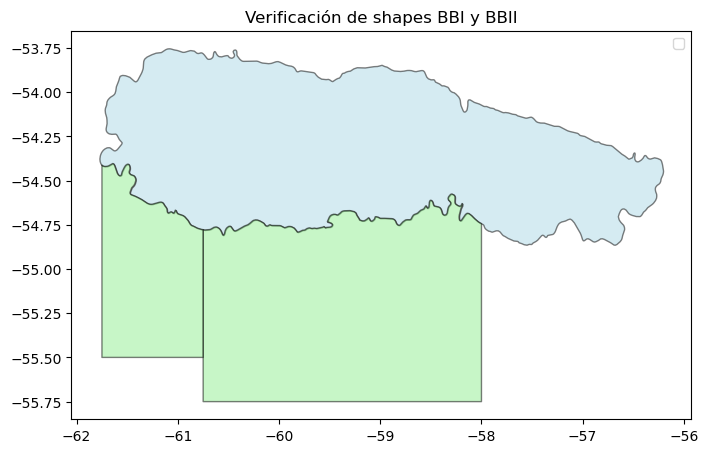

In [19]:
fig, ax = plt.subplots(figsize=(8,8))
bbi_shape.plot(ax=ax, color="lightblue", edgecolor="black", alpha=0.5, label="BBI")
bbii_shape.plot(ax=ax, color="lightgreen", edgecolor="black", alpha=0.5, label="BBII")
ax.set_title("Verificación de shapes BBI y BBII")
ax.legend()
plt.show()


C:\Users\gisel\AppData\Local\Temp\ipykernel_63888\2178318223.py:10: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  bbii_union = bbii_shape.unary_union   # devuelve un MultiPolygon o Polygon unificado
C:\Users\gisel\AppData\Local\Temp\ipykernel_63888\2178318223.py:22: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
C:\Users\gisel\AppData\Local\Temp\ipykernel_63888\2178318223.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


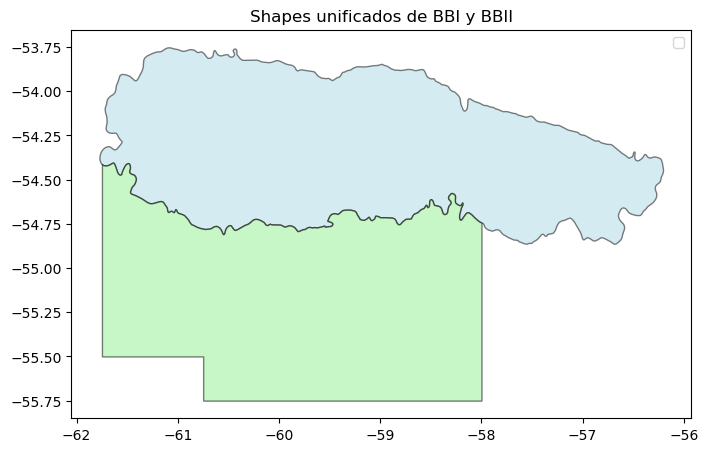

In [20]:
# --- 1️⃣ CARGAR SHAPES ---
bbi_shp_path = os.path.join(SHAPES_DIR, "transicion_solo.shp")   # BBI
bbii_shp_path = os.path.join(SHAPES_DIR, "Burdwood_2.shp")       # BBII (dos polígonos)

bbi_shape = gpd.read_file(bbi_shp_path)
bbii_shape = gpd.read_file(bbii_shp_path)

# --- 2️⃣ UNIFICAR POLÍGONOS DE BBII ---
# Si el shapefile tiene más de un polígono, los combinamos en uno solo
bbii_union = bbii_shape.unary_union   # devuelve un MultiPolygon o Polygon unificado

# Opcional: guardar como nuevo GeoDataFrame para manejarlo igual que bbi
bbii_shape_union = gpd.GeoDataFrame({"name": ["BBII"]}, geometry=[bbii_union], crs=bbii_shape.crs)

# --- 3️⃣ GRAFICAR ---
fig, ax = plt.subplots(figsize=(8,8))

bbi_shape.plot(ax=ax, color="lightblue", edgecolor="black", alpha=0.5, label="BBI")
bbii_shape_union.plot(ax=ax, color="lightgreen", edgecolor="black", alpha=0.5, label="BBII (unido)")

ax.set_title("Shapes unificados de BBI y BBII")
ax.legend()
plt.show()


   FID                                           geometry
0    0  POLYGON ((-58 -55.75, -60.75 -55.75, -60.75 -5...


<Axes: >

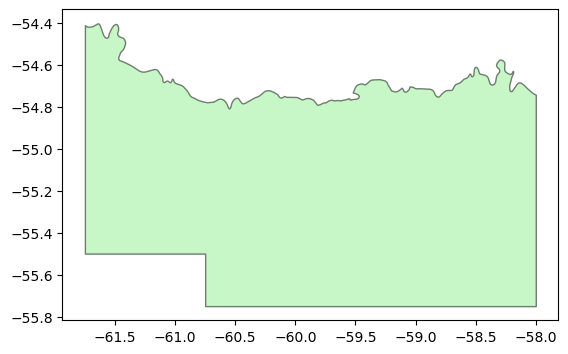

In [22]:
bbii_union_path = os.path.join(SHAPES_DIR, "BBII_unificado.shp")

bbii_shape_union = gpd.read_file(bbii_union_path)
print(bbii_shape_union)
bbii_shape_union.plot(edgecolor='black', facecolor='lightgreen', alpha=0.5)

In [21]:
print(os.getcwd())


C:\Users\gisel\BB_stress_paper\notebooks


### Guardamos los shapes

In [23]:
from shapely.ops import unary_union

# --- 1️⃣ Unificar polígonos de BBII ---
# Si bbii_shape tiene más de un polígono
bbii_unificado = unary_union(bbii_shape.geometry)

# Crear un GeoDataFrame nuevo
import geopandas as gpd
bbii_gdf = gpd.GeoDataFrame(geometry=[bbii_unificado], crs=bbii_shape.crs)

# --- 2️⃣ Guardar el nuevo shapefile ---
output_path = "../data/raw/shapes/BBII_unificado.shp"
bbii_gdf.to_file(output_path)

print(f"Shape unificado guardado en: {output_path}")

Shape unificado guardado en: ../data/raw/shapes/BBII_unificado.shp


In [24]:
import xarray as xr


Batimetria

In [8]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [9]:
# NetCDF de batimetría
gebco_path = os.path.join(SHAPES_DIR, "gebco_2025_n-52.0_s-56.0_w-63.0_e-54.0.nc")

# Shapes de BBI y BBII
bbi_shp_path = os.path.join(SHAPES_DIR, "transicion_solo.shp")
bbii_shp_path = os.path.join(SHAPES_DIR, "Burdwood_2_unificado.shp")

In [12]:
ds = xr.open_dataset(gebco_path)
bath = ds['elevation']


C:\Users\gisel\anaconda3\envs\BB_stress_paper\Lib\site-packages\cartopy\io\__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
C:\Users\gisel\anaconda3\envs\BB_stress_paper\Lib\site-packages\cartopy\io\__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


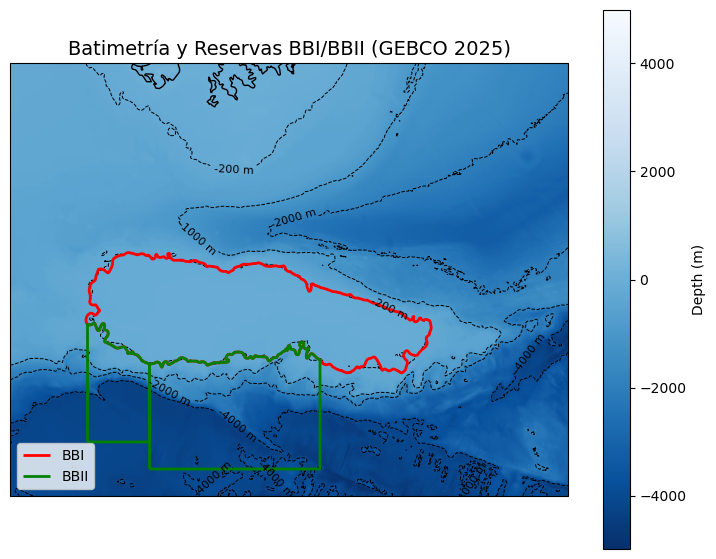

In [14]:
# --- 3️⃣ Crear figura ---
plt.figure(figsize=(9,7))
ax = plt.axes(projection=ccrs.PlateCarree())

# Batimetría
bath.plot(
    ax=ax, transform=ccrs.PlateCarree(),
    cmap="Blues_r",
    cbar_kwargs={'label': 'Depth (m)'}
)

# Isóbatas (200, 1000, 2000, 4000 m)
contours = bath.plot.contour(
    ax=ax, transform=ccrs.PlateCarree(),
    levels=[-200, -1000, -2000, -4000],
    colors='k', linewidths=0.7
)
ax.clabel(contours, fmt='%d m', fontsize=8)

# --- 4️⃣ Agregar shapes ---
bbi_shape.boundary.plot(ax=ax, edgecolor="red", linewidth=2, label="BBI")
bbii_shape.boundary.plot(ax=ax, edgecolor="green", linewidth=2, label="BBII")

# --- 5️⃣ Extras ---
ax.coastlines(resolution="10m", color="black", linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.legend(loc="lower left")
plt.title("Batimetría y Reservas BBI/BBII (GEBCO 2025)", fontsize=14)

plt.show()

CORTANDO LOS DATOS CON LA FORMA DE LOS SHAPES

In [30]:
# === Cargar shapes ===
bbi_shp_path = os.path.join(SHAPES_DIR, "transicion_solo.shp")
bbii_shp_path = os.path.join(SHAPES_DIR, "BBII_unificado.shp")

bbi = gpd.read_file(bbi_shp_path)
bbii = gpd.read_file(bbii_shp_path)

# --- Función para recortar por polígono ---
def mask_polygon(ds, gdf):
    """
    Recorta un Dataset de xarray con un polígono de GeoDataFrame.
    Compatible con datasets 3D o 4D (time, depth, lat, lon).
    """
    # Unir polígonos si hay más de uno
    polygon = gdf.geometry.union_all() if hasattr(gdf.geometry, "union_all") else gdf.geometry.unary_union
    
    # Obtener coordenadas
    lon, lat = np.meshgrid(ds['longitude'], ds['latitude'])
    points = gpd.GeoSeries(gpd.points_from_xy(lon.ravel(), lat.ravel()), crs="EPSG:4326")
    
    # Crear máscara 2D (lat, lon)
    mask2d = points.within(polygon).values.reshape(lat.shape)
    
    # Expandir máscara según dimensiones
    if 'time' in ds.dims:
        mask = np.broadcast_to(mask2d, (ds.sizes['time'], ds.sizes['latitude'], ds.sizes['longitude']))
        mask = xr.DataArray(mask, dims=('time', 'latitude', 'longitude'))
    elif 'depth' in ds.dims and 'time' in ds.dims:
        mask = np.broadcast_to(mask2d, (ds.sizes['time'], ds.sizes['depth'], ds.sizes['latitude'], ds.sizes['longitude']))
        mask = xr.DataArray(mask, dims=('time', 'depth', 'latitude', 'longitude'))
    else:
        mask = xr.DataArray(mask2d, dims=('latitude', 'longitude'))
    
    return ds.where(mask)

In [32]:
import numpy as np


In [33]:
# === SST ===
sst_path = os.path.join(DATA_RAW_DIR, "SST", "sst_combined.nc")
ds_sst = xr.open_dataset(sst_path)

# Recortes por shape
ds_sst_bbi = mask_polygon(ds_sst, bbi)
ds_sst_bbii = mask_polygon(ds_sst, bbii)

# Guardar
out_dir = os.path.join(DATA_PROCESSED_DIR, "SST")
os.makedirs(out_dir, exist_ok=True)

ds_sst_bbi.to_netcdf(os.path.join(out_dir, "sst_BBI.nc"))
ds_sst_bbii.to_netcdf(os.path.join(out_dir, "sst_BBII.nc"))
ds_sst.to_netcdf(os.path.join(out_dir, "sst_bbox.nc"))  # el recorte cuadrado original

In [34]:
# === pH ===
ph_path = os.path.join(DATA_RAW_DIR, "pH", "cmems_obs-mob_glo_bgc-car_my_irr-i_1756152669355.nc")
ds_ph = xr.open_dataset(ph_path)

# Recortes por shape
ds_ph_bbi = mask_polygon(ds_ph, bbi)
ds_ph_bbii = mask_polygon(ds_ph, bbii)

# Guardar
out_dir = os.path.join(DATA_PROCESSED_DIR, "pH")
os.makedirs(out_dir, exist_ok=True)

ds_ph_bbi.to_netcdf(os.path.join(out_dir, "ph_BBI.nc"))
ds_ph_bbii.to_netcdf(os.path.join(out_dir, "ph_BBII.nc"))
ds_ph.to_netcdf(os.path.join(out_dir, "ph_bbox.nc"))

In [35]:
# === O2 Hindcast ===
o2_hindcast_path = os.path.join(DATA_RAW_DIR, "Oxigeno", "cmems_mod_glo_bgc_my_0.25deg_P1M-m_1757960017296.nc")
ds_o2 = xr.open_dataset(o2_hindcast_path)

# Recortes por shape
ds_o2_bbi = mask_polygon(ds_o2, bbi)
ds_o2_bbii = mask_polygon(ds_o2, bbii)

# Guardar
out_dir = os.path.join(DATA_PROCESSED_DIR, "O2")
os.makedirs(out_dir, exist_ok=True)

ds_o2_bbi.to_netcdf(os.path.join(out_dir, "o2_hindcast_BBI.nc"))
ds_o2_bbii.to_netcdf(os.path.join(out_dir, "o2_hindcast_BBII.nc"))
ds_o2.to_netcdf(os.path.join(out_dir, "o2_hindcast_bbox.nc"))

In [37]:
import pandas as pd


In [38]:
# === O2 Observaciones (GLODAP) ===
glodap_path = os.path.join(DATA_RAW_DIR, "Oxigeno", "cmems_obs-ins_glo_bgc-car_my_glodap-obs_irr_1757964471340.csv")

df_glodap = pd.read_csv(glodap_path, comment="#")
gdf_glodap = gpd.GeoDataFrame(df_glodap, geometry=gpd.points_from_xy(df_glodap.longitude, df_glodap.latitude), crs="EPSG:4326")

# Recortes por shape
gdf_glodap_bbi = gdf_glodap[gdf_glodap.within(bbi.geometry.unary_union)]
gdf_glodap_bbii = gdf_glodap[gdf_glodap.within(bbii.geometry.unary_union)]

# Guardar
out_dir = os.path.join(DATA_PROCESSED_DIR, "O2")
os.makedirs(out_dir, exist_ok=True)

gdf_glodap_bbi.to_csv(os.path.join(out_dir, "o2_glodap_BBI.csv"), index=False)
gdf_glodap_bbii.to_csv(os.path.join(out_dir, "o2_glodap_BBII.csv"), index=False)
gdf_glodap.to_csv(os.path.join(out_dir, "o2_glodap_bbox.csv"), index=False)

C:\Users\gisel\AppData\Local\Temp\ipykernel_63888\2940310662.py:8: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  gdf_glodap_bbi = gdf_glodap[gdf_glodap.within(bbi.geometry.unary_union)]
C:\Users\gisel\AppData\Local\Temp\ipykernel_63888\2940310662.py:9: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  gdf_glodap_bbii = gdf_glodap[gdf_glodap.within(bbii.geometry.unary_union)]
